In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
import sys
sys.path.append('../python')
import utils

# The second run for test
THe first run was using TATT model for 2pt.
Now we use NLA model consistently to see the improvement in the IA parameter constraint.

In [3]:
def get(fname):
    chain, params, labels, ranges = utils.read_cosmosis_mcmc_des_chain(fname, take=['om', 's8', 'sig8', 'a1', 'a2', 'alpha1', 'alpha2', 'map3-chi2'])
    samples = utils.chain_to_mcsamples(chain, params, labels)
    utils.wplot(chain, params, labels)
    return samples

Blinding  ['om', 'h0', 'cosmological_parameters--omega_b', 'cosmological_parameters--n_s', 's8', 'cosmological_parameters--mnu', 'sig8', 'COSMOLOGICAL_PARAMETERS--SIGMA_12']
Removed no burn in


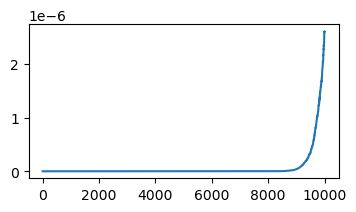

Blinding  ['om', 'h0', 'cosmological_parameters--omega_b', 'cosmological_parameters--n_s', 's8', 'cosmological_parameters--mnu', 'sig8', 'COSMOLOGICAL_PARAMETERS--SIGMA_12']
Removed no burn in


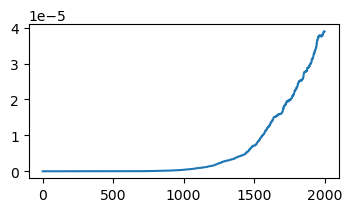

Blinding  ['om', 'h0', 'cosmological_parameters--omega_b', 'cosmological_parameters--n_s', 's8', 'cosmological_parameters--mnu', 'sig8', 'COSMOLOGICAL_PARAMETERS--SIGMA_12']
Removed no burn in


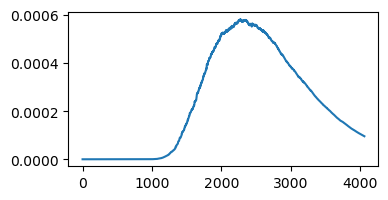

In [4]:
#samples_2pt_map3_auto_334_344 = get('../output/test-desy3c-run/des-y3-2pt-map3-auto-334-344.txt')
samples_2pt_map3_auto = get('../output/blind-metacal/des-y3-2pt-map3-auto.txt')
samples_map3 = get('../output/blind-metacal/des-y3-map3-blind-metacal.txt')
samples_2pt = get('../output/blind-metacal/des-y3-2pt-blind-metacal.txt')
#samples_emu_2pt_map3_all_rescaled = samples_emu_2pt_map3_all.copy()
#samples_emu_2pt_map3_all_rescaled.weights /= 2.5**2

In [ ]:
g = plots.get_single_plotter(ratio=1, width_inch=8)
g.triangle_plot([samples_2pt, samples_2pt_map3_auto_334_344], ['om', 's8', 'sig8', 'a1', 'alpha1'], filled=False, \
    legend_labels=['2pt', '2pt+map3(auto+334+344)'], legend_loc='upper right', 
    markers={'om': 0.29, 's8':0.759, 'sig8': 0.772, 'a1':0.7, 'alpha1':-1.7})
plt.show()

In [ ]:
names = ['s8', 'om']
samples_list = [samples_2pt, samples_2pt_map3_auto_334_344]
fom = np.array([utils.FoM_from_samples_names(s, names) for s in samples_list])
improve = fom/fom[0]

In [ ]:
fom

In [ ]:
improve

In [ ]:
g = plots.get_single_plotter(ratio=1, width_inch=8)
g.triangle_plot([samples_2pt, samples_emu_2pt_map3_all], ['om', 's8', 'sig8', 'a1', 'alpha1'], filled=False, \
    legend_labels=['2pt', '2pt+map3(emu w/ all data)'], legend_loc='upper right', 
    markers={'om': 0.29, 's8':0.759, 'sig8': 0.772, 'a1':0.7, 'alpha1':-1.7})
plt.show()
#plt.savefig("2pt_map3_emu_all_24May24.pdf")

In [ ]:
names = ['om','s8']
samples_list = [samples_2pt, samples_emu_2pt_map3_all]
fom = np.array([utils.FoM_from_samples_names(s, names) for s in samples_list])
improve = fom/fom[0]

In [ ]:
print(fom)

In [ ]:
print(improve)

In [ ]:
names = samples_emu_2pt_map3_all.paramNames.getRunningNames()
s = samples_emu_2pt_map3_all.samples
w = samples_emu_2pt_map3_all.weights

s8 = s[:, names.index('s8')]
om = s[:, names.index('om')]
sg8= s[:, names.index('sig8')]
a1= s[:, names.index('a1')]
alpha1= s[:, names.index('alpha1')]
map3chi2 = s[:, names.index('map3-chi2')]

#temp = 2**2
temp = 1/0.31
w2= w*np.exp(-map3chi2/2.0*temp + map3chi2/2.0)

samples_emu_2pt_map3_all_v2 = MCSamples(samples=[s8, om, sg8, a1, alpha1], weights=w2, names=['s8', 'om', 'sig8', 'a1', 'alpha1'], labels=['S_8', '\Omega_{\rm m}', '\sigma_8', 'a1', 'alpha1'])

In [ ]:
g = plots.get_single_plotter(ratio=1, width_inch=8)
g.triangle_plot([samples_2pt, samples_emu_2pt_map3_all_res_cov], ['om', 's8', 'sig8', 'a1', 'alpha1'], filled=False, \
    legend_labels=['2pt', '2pt+map3(emu w/ rescaled cov)'], legend_loc='upper right', 
    markers={'om': 0.29, 's8':0.759, 'sig8': 0.772})
#plt.show()
plt.savefig("2pt_map3_emu_all_combinations_rescaled_covariance.pdf")

In [ ]:
names = ['om','s8']
samples_list = [samples_2pt, samples_emu_2pt_map3_all_res_cov]
fom = np.array([utils.FoM_from_samples_names(s, names) for s in samples_list])
improve = fom/fom[0]

In [ ]:
fom

In [ ]:
improve

# signal

In [ ]:
import threepoint

In [ ]:
thpt = threepoint.ThreePointDataClass.from_fits('../data/dv/sim_map3-NLA-cosmoDESY3.fits')
print(thpt.get_snr())
fig = thpt.plot(yscale='linear', nt=4)

## Forecast

In [ ]:
names = samples_2pt_map3_auto_334_344.paramNames.getRunningNames()
s = samples_2pt_map3_auto_334_344.samples
w = samples_2pt_map3_auto_334_344.weights

s8 = s[:, names.index('s8')]
om = s[:, names.index('om')]
sg8= s[:, names.index('sig8')]
map3chi2 = s[:, names.index('map3-chi2')]

temp = 2**2 /0.842
w2= w*np.exp(-map3chi2/2.0*temp + map3chi2/2.0)

samples_2pt_map3_auto_334_344_v2 = MCSamples(samples=[s8, om, sg8], weights=w2, names=['s8', 'om', 'sig8'], labels=['S_8', '\Omega_{\rm m}', '\sigma_8'])

In [ ]:
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.triangle_plot([samples_2pt, samples_2pt_map3_auto_334_344, samples_2pt_map3_auto_334_344_v2], 
    ['om', 's8', 'sig8'], filled=False, \
    legend_labels=['2pt', '2pt+map3(auto+334+344)', 'x2'], legend_loc='upper right', 
    markers={'om': 0.29, 's8':0.759, 'sig8': 0.772, 'a1':0.7, 'alpha1':-1.7})
plt.show()

g = plots.get_single_plotter(ratio=1, width_inch=6)
g.triangle_plot([samples_2pt, samples_2pt_map3_auto_334_344_v2], 
    ['om', 's8', 'sig8'], filled=False, \
    legend_labels=['2pt', 'x2'], legend_loc='upper right', 
    markers={'om': 0.29, 's8':0.759, 'sig8': 0.772, 'a1':0.7, 'alpha1':-1.7})
plt.show()

In [ ]:
names = ['s8', 'om']
samples_list = [samples_2pt, samples_2pt_map3_auto_334_344, samples_2pt_map3_auto_334_344_v2]
fom = np.array([utils.FoM_from_samples_names(s, names) for s in samples_list])
improve = fom/fom[0]

In [ ]:
fom

In [ ]:
improve

In [ ]:
import threepoint

In [ ]:
thpt = threepoint.ThreePointDataClass.from_fits('../data/dv/sim_map3-NLA-cosmoDESY3.fits')
print(thpt.get_snr())
fig = thpt.plot(yscale='linear', nt=4)

In [ ]:
thpt.reduce_by_z_bin_selection(['auto', '3,3,4', '3,4,4'])

In [ ]:
print(thpt.get_snr())
fig = thpt.plot(yscale='log')

In [ ]:
np.diag(thpt.get_covariance())**0.5

In [ ]:
thpt.get_t_bin()[0,:]

In [ ]:
1e-8/25

In [ ]:
0.95**(1.0/4.0)

In [ ]:
0.9872585449014338**8

In [ ]:
thpt2 = threepoint.ThreePointDataClass.from_fits('../data/nz/map3_dv_COSMOGRID_19Apr24.fits')
# thpt2 = threepoint.ThreePointDataClass.from_fits('../data/nz/map3_dv_NOISY_COSMOGRID_11Apr24_ALL_ZCORRELATIONS_320SIMS.fits')
print(thpt2.get_snr())
fig = thpt2.plot(yscale='linear', nt=4)

In [ ]:
((400 - 80 - 2)/(400-1))**0.5

In [ ]:
thpt1 = threepoint.ThreePointDataClass.from_fits('../data/dv/sim_map3-NLA-cosmoDESY3.fits')
thpt2 = threepoint.ThreePointDataClass.from_fits('../data/nz/map3_dv_COSMOGRID_19Apr24.fits')

In [ ]:
plt.plot(thpt1.get_signal(), marker='o')
plt.plot(thpt2.get_signal(), marker='o')
plt.show()

In [ ]:
plt.plot(thpt2.get_signal()/thpt1.get_signal(), marker='o')
plt.ylim(0.0, 4.0)
plt.show()